In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
team_stats = pd.read_csv('Agg_Team_Data_2000-2024.csv')

In [3]:
team_stats = team_stats[team_stats['season'] < 2023]
team_stats.columns

Index(['season', 'teamId', 'teamName', 'games_played', 'wins', 'losses',
       'avg_points', 'avg_opponent_points', 'avg_point_diff', 'fg_pct',
       'three_pct', 'ft_pct', 'assists', 'rebounds', 'turnovers', 'steals',
       'blocks', 'fastbreak_pts', 'paint_pts', 'second_chance_pts',
       'points_from_to', 'biggest_lead', 'times_tied', 'lead_changes',
       'def_rebounds', 'off_rebounds', 'personal_fouls', 'plus_minus_pts',
       'off_efficiency', 'win_pct', 'avg_margin', 'playoff_games',
       'playoff_wins', 'playoff_losses', 'payroll', 'inflationAdjPayroll'],
      dtype='object')

In [4]:
team_stats['playoff_wins'].mean()

np.float64(2.793296089385475)

#### An initial, very rudimentary model could predict 3 games won, although any one team is not probable to recieve 3 wins

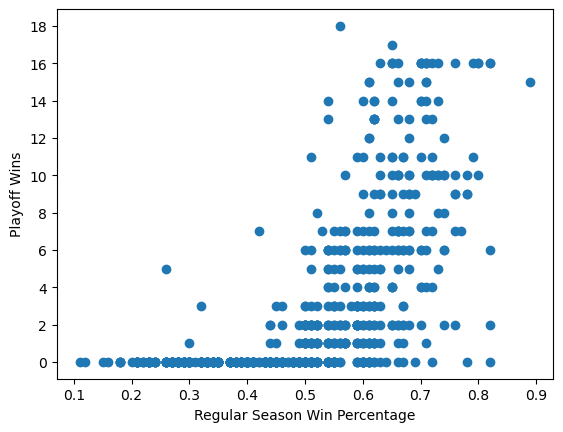

In [5]:
plt.scatter(team_stats['win_pct'], team_stats['playoff_wins'])
plt.xlabel("Regular Season Win Percentage")
plt.ylabel("Playoff Wins")
plt.yticks(np.arange(0, 20, 2))
plt.show()

/tmp/ipykernel_20133/374909891.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_wins = team_stats.groupby(


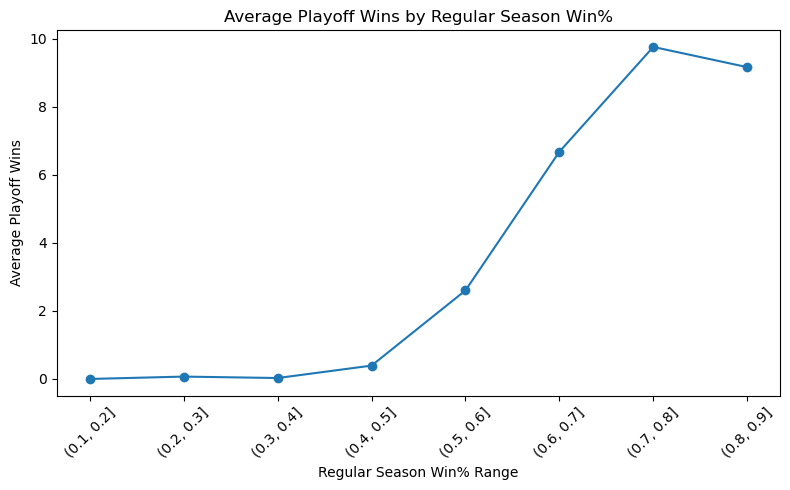

In [6]:
avg_wins = team_stats.groupby(
    pd.cut(team_stats['win_pct'], bins=np.arange(0, 1.05, 0.1))
)['playoff_wins'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_wins.index.astype(str), avg_wins.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Regular Season Win% Range')
plt.ylabel('Average Playoff Wins')
plt.title('Average Playoff Wins by Regular Season Win%')
plt.tight_layout()
plt.show()

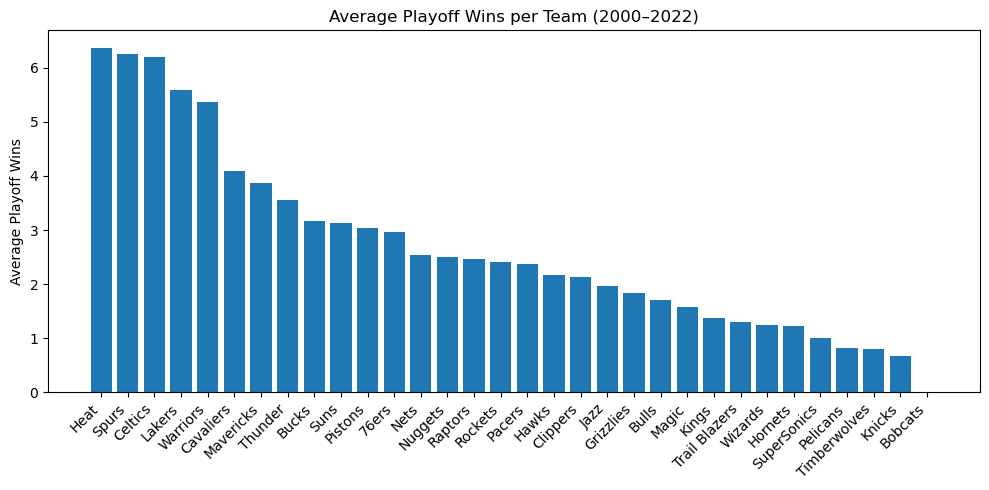

In [7]:
avg_wins = (
    team_stats.groupby('teamName')['playoff_wins']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(avg_wins.index, avg_wins.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Playoff Wins')
plt.title('Average Playoff Wins per Team (2000–2022)')
plt.tight_layout()
plt.show()

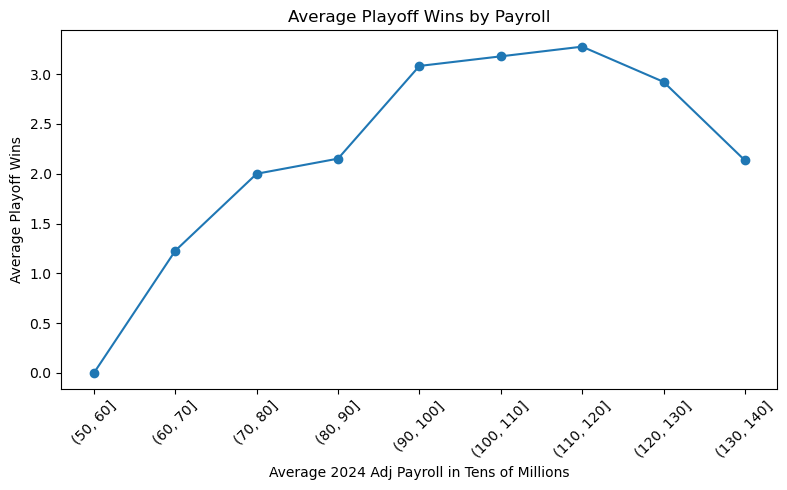

In [8]:
avg_wins = team_stats.groupby(
    pd.cut((team_stats['inflationAdjPayroll'] / 1_000_000), bins=np.arange(50, 150, 10)), observed=False
)['playoff_wins'].mean()


plt.figure(figsize=(8,5))
plt.plot(avg_wins.index.astype(str), avg_wins.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Average 2024 Adj Payroll in Tens of Millions')
plt.ylabel('Average Playoff Wins')
plt.title("Average Playoff Wins by Payroll")
plt.tight_layout()
plt.show()

In [27]:
team_stats['win_pct_binned'] = pd.cut(team_stats['win_pct'], bins = np.arange(0.3, 1.01, .05))

binned_means = round(team_stats.groupby('win_pct_binned')['playoff_wins'].mean(), 0)

binned_means

/tmp/ipykernel_20133/633595730.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = round(team_stats.groupby('win_pct_binned')['playoff_wins'].mean(), 0)


win_pct_binned
(0.3, 0.35]     0.0
(0.35, 0.4]     0.0
(0.4, 0.45]     0.0
(0.45, 0.5]     0.0
(0.5, 0.55]     2.0
(0.55, 0.6]     3.0
(0.6, 0.65]     5.0
(0.65, 0.7]     8.0
(0.7, 0.75]    10.0
(0.75, 0.8]     9.0
(0.8, 0.85]    10.0
(0.85, 0.9]    15.0
(0.9, 0.95]     NaN
(0.95, 1.0]     NaN
Name: playoff_wins, dtype: float64

In [28]:
team_stats['baseline_pred'] = team_stats['win_pct_binned'].map(binned_means).fillna(0)


In [41]:
mae_zero = team_stats['playoff_wins'].abs().mean()

mae_base = (team_stats['playoff_wins'] - team_stats['baseline_pred']).abs().mean()

mae_base < mae_zero

np.True_

In [55]:
mean_absolute_error(team_stats['playoff_wins'], team_stats['baseline_pred'])

1.7276536312849162

In [44]:
print("MAE base: ", mae_base)
print("MAE Zero: ", mae_zero)


MAE base:  1.7276536312849162
MAE Zero:  2.793296089385475


In [46]:
X = team_stats[['win_pct']]
y = team_stats['playoff_wins']

In [51]:
baseline_model = LinearRegression()

baseline_model.fit(X, y)

team_stats['ols_predict'] = baseline_model.predict(X)

print("Intercept:", baseline_model.intercept_)
print("Coefficient:", baseline_model.coef_)

Intercept: -6.825337214310705
Coefficient: [19.23726661]


In [53]:
ols_mae = mean_absolute_error(team_stats['playoff_wins'], team_stats['ols_predict'])
ols_mae

2.5070231812494246

In [61]:
team_stats

,season,teamId,teamName,games_played,wins,losses,avg_points,avg_opponent_points,avg_point_diff,fg_pct,...,avg_margin,playoff_games,playoff_wins,playoff_losses,payroll,inflationAdjPayroll,win_pct_binned,baseline_pred,ols_predict,poisson_pred
0,2000,1610612737,Hawks,82,25,57,90.96,96.17,-5.00,0.43,...,-5.21,0.0,0.0,0.0,39297129.0,6.754159e+07,NaN,0.0,-1.054157,2.574722
1,2000,1610612738,Celtics,82,36,46,94.62,96.76,-2.13,0.43,...,-2.13,0.0,0.0,0.0,51478707.0,8.847857e+07,"(0.4, 0.45]",0.0,1.639060,2.722522
2,2000,1610612739,Cavaliers,82,30,52,92.21,96.45,-4.24,0.44,...,-4.24,0.0,0.0,0.0,49780549.0,8.555988e+07,"(0.35, 0.4]",0.0,0.292451,2.647591
3,2000,1610612741,Bulls,82,15,67,87.57,96.67,-9.10,0.43,...,-9.10,0.0,0.0,0.0,29691907.0,5.103270e+07,NaN,0.0,-3.362629,2.454438
4,2000,1610612742,Mavericks,82,53,29,100.48,96.20,4.28,0.46,...,4.28,10.0,4.0,6.0,52274842.0,8.984692e+07,"(0.65, 0.7]",8.0,5.678886,2.960283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2022,1610612762,Jazz,82,37,45,117.07,118.01,-0.94,0.47,...,-0.94,0.0,0.0,0.0,179567255.0,1.924733e+08,"(0.45, 0.5]",0.0,1.831433,2.733399
712,2022,1610612763,Grizzlies,82,51,31,116.91,112.98,3.94,0.48,...,3.94,6.0,2.0,4.0,103896997.0,1.113644e+08,"(0.6, 0.65]",5.0,5.101768,2.925086
713,2022,1610612764,Wizards,82,35,47,113.16,114.37,-1.21,0.49,...,-1.21,0.0,0.0,0.0,146800955.0,1.511308e+08,"(0.4, 0.45]",0.0,1.446687,2.711689
714,2022,1610612765,Pistons,82,17,65,110.30,118.52,-7.88,0.45,...,-8.22,0.0,0.0,0.0,92249812.0,9.888008e+07,NaN,0.0,-2.785511,2.483972
